In [16]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
import torch.optim as optim
from torchvision.utils import save_image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


In [2]:
# ===========================================
# 🔗 MOUNT GOOGLE DRIVE
# ===========================================
# This step is only for Google Colab users
# It lets you access your datasets stored on Google Drive

from google.colab import drive
drive.mount('/content/drive')

# After this, your Drive files will be available under `/content/drive/MyDrive`


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# extract the images from the tar file
! tar -xf "/content/drive/MyDrive/datasets/anime-faces.tar.gz"

In [4]:
# Declare some constants

img_size = 64
root_folder = "/content/anime-faces"
batch_size = 128
nc = 3 # number of channels in an image (RGB)
ngf = 64 # number of features in the encoder
ndf = 64 # number of channels in the decoder
nz = 100 # dimension of the latent space
lr = 0.0002 # learning rate for the networks
num_epochs = 100 # total number of training epochs
save_dir = "/content/vae_log/"

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


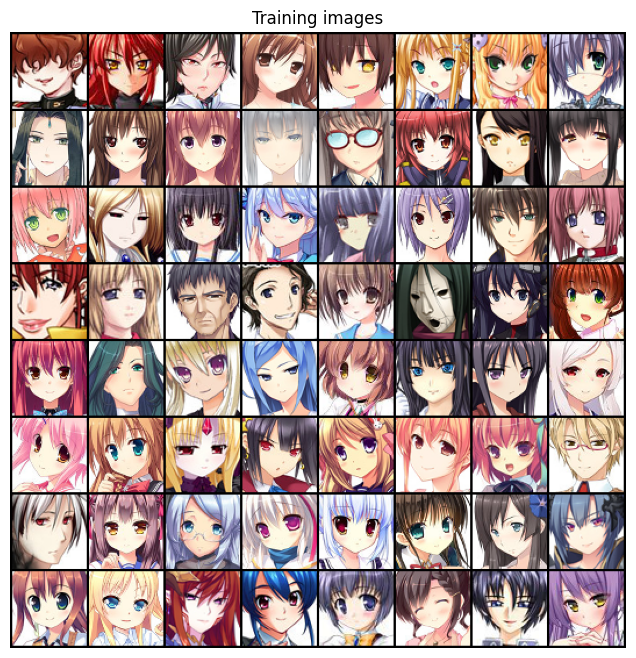

In [17]:
# create a set of transforms for the dataset
dset_transforms = list()
dset_transforms.append(transforms.Resize(img_size))
dset_transforms.append(transforms.ToTensor())
dset_transforms.append(transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                            std=[0.5, 0.5, 0.5]))
dset_transforms = transforms.Compose(dset_transforms)

# create a dataset using ImageFolder of pytorch
dataset = dset.ImageFolder(root=root_folder, transform=dset_transforms)

# create a data loader
dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=4,
                        shuffle=True, drop_last=True)

# Plot images
fixed_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(vutils.make_grid(fixed_batch[0][:64], padding=2,
                                         normalize=True), (1, 2, 0)))

In [18]:
def reparameterize(mu, logvar):
    """
    Apply the reparameterization trick:
    z = μ + σ * ε
    where ε ~ N(0, 1)

    This allows backpropagation through the sampling operation.
    """

    # Compute standard deviation from log-variance
    std = torch.exp(0.5 * logvar)

    # Sample epsilon from a standard normal distribution
    eps = torch.randn_like(std)

    # Reparameterized sample
    return mu + eps * std


In [19]:
class Encoder(nn.Module):
    """
    Encoder network for the Variational Autoencoder (VAE).
    Input: 3×64×64 anime face image.
    Output: mean (mu) and log-variance (logvar) of latent distribution.
    """

    def __init__(self, latent_dim=128):
        super().__init__()

        # Convolutional feature extractor: progressively downsamples the image
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # Output: 32×32×32
            nn.ReLU(True),

            nn.Conv2d(32, 64, 4, 2, 1),  # Output: 64×16×16
            nn.ReLU(True),

            nn.Conv2d(64, 128, 4, 2, 1),  # Output: 128×8×8
            nn.ReLU(True),

            nn.Conv2d(128, 256, 4, 2, 1),  # Output: 256×4×4
            nn.ReLU(True)
        )

        # Flatten and predict μ and logσ² for latent vector
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        # Extract features
        x = self.conv(x)
        # Flatten feature maps into a vector
        x = x.view(x.size(0), -1)

        # Output latent distribution parameters
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar


In [20]:
class Decoder(nn.Module):
    """
    Decoder network: reconstructs images from latent vector z.
    Output size: 3×64×64 (same as input)
    """

    def __init__(self, latent_dim=128):
        super().__init__()

        # Map latent vector into a 4×4×256 feature map
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        # Upsample using transposed convolutions
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # Output: 128×8×8
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # Output: 64×16×16
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # Output: 32×32×32
            nn.ReLU(True),

            # Final layer outputs RGB image (0–1 range)
            nn.ConvTranspose2d(32, 3, 4, 2, 1),     # Output: 3×64×64
            nn.Sigmoid()  # Ensures pixel values are between 0 and 1
        )

    def forward(self, z):
        # Expand latent vector into feature map
        x = self.fc(z)
        x = x.view(z.size(0), 256, 4, 4)
        # Upsample and reconstruct image
        return self.deconv(x)


In [21]:
class VAE(nn.Module):
    """
    Full Variational Autoencoder:
    Encodes input → samples latent z → decodes reconstruction.
    """

    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        # Encode → get μ and logσ²
        mu, logvar = self.encoder(x)

        # Sample latent vector z
        z = reparameterize(mu, logvar)

        # Decode reconstructed image
        recon = self.decoder(z)

        return recon, mu, logvar


In [22]:
def vae_loss(recon, x, mu, logvar):
    """
    Computes the VAE loss = reconstruction loss + KL divergence.
    - Reconstruction loss encourages accurate image reconstruction
    - KL divergence pushes latent distribution toward N(0, 1)
    """

    # Pixel-wise MSE loss
    recon_loss = F.mse_loss(recon, x, reduction='sum')

    # KL divergence between predicted distribution and N(0,1) --> Kullback-Leibler Divergence Loss
    # kl = ???   KL(q∥p)=−1/2 * ​∑(1+logσ2−μ2−σ2)
    kl = -0.5 * torch.sum(1+logvar -mu.pow(2) - logvar.pow(2))
    # Normalize by batch size
    return (recon_loss + kl) / x.size(0)


In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

latent_dim = 128
vae = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

# Load the saved weights
save_path = "/content/drive/MyDrive/datasets/vae_cifar100.pth"
vae.load_state_dict(torch.load(save_path, map_location=device))
print('loaded model')
epochs = 3

for epoch in range(epochs):

    for imgs, _ in dataloader:
        imgs = imgs.to(device)

        optimizer.zero_grad()

        # Forward pass: reconstruct images
        recon, mu, logvar = vae(imgs)

        # Compute total VAE loss
        loss = vae_loss(recon, imgs, mu, logvar)

        # Backpropagation
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")


loaded model
Epoch 1/3 | Loss: 1799.1212
Epoch 2/3 | Loss: 1931.7920
Epoch 3/3 | Loss: 1844.7449


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


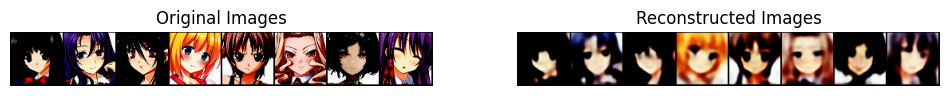

In [ ]:
vae.eval()

with torch.no_grad():
    imgs, _ = next(iter(dataloader))
    imgs = imgs.to(device)

    # Get reconstructed images
    recon, _, _ = vae(imgs)

    # Build image grids
    grid_real = make_grid(imgs[:8], nrow=8)
    grid_recon = make_grid(recon[:8], nrow=8)

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Original Images")
plt.imshow(grid_real.permute(1,2,0).cpu())
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed Images")
plt.imshow(grid_recon.permute(1,2,0).cpu())
plt.axis("off")

plt.show()


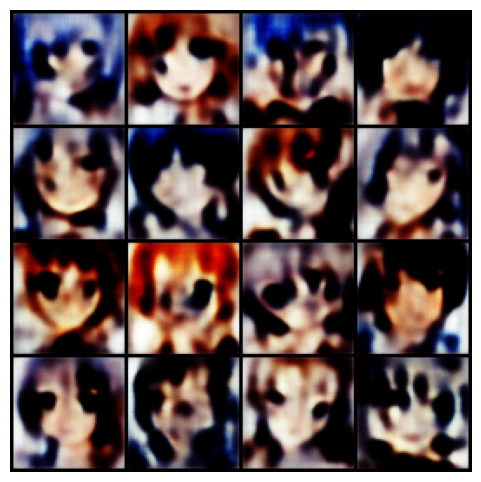

In [ ]:
vae.eval()

with torch.no_grad():
    # Random latent vectors from standard normal
    z = torch.randn(16, latent_dim).to(device)

    # Decode synthetic images
    samples = vae.decoder(z)

    grid = make_grid(samples, nrow=4)

# Display generated images
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.show()

In [24]:
def interpolate(mu1, mu2, num_steps=10):
    """
    Linearly interpolate between two latent vectors.
    Returns a list of latent vectors.

    mu1, mu2: latent vectors (1×latent_dim)
    num_steps: number of interpolation points
    """
    # Generate alpha values between 0 and 1
    alphas = torch.linspace(0, 1, steps=num_steps).to(mu1.device)

    # z = (1 - α) * z1 + α * z2
    return [(1-a)*mu1 + a*mu2 for a in alphas]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


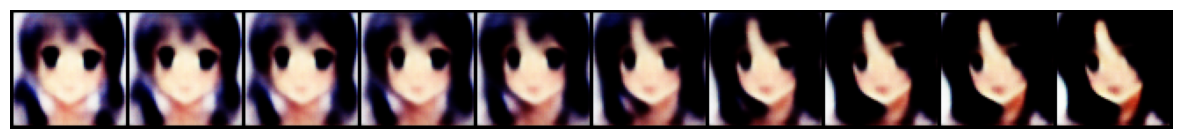

In [25]:
vae.eval()

with torch.no_grad():
    # Get two images from your dataset
    imgs, _ = next(iter(dataloader))
    img1 = imgs[0].unsqueeze(0).to(device)
    img2 = imgs[1].unsqueeze(0).to(device)

    # Encode → get μ (use μ as the representative latent vector)
    mu1, _ = vae.encoder(img1)
    mu2, _ = vae.encoder(img2)

    # Interpolate in latent space
    z_list = interpolate(mu1, mu2, num_steps=10)

    # Decode each interpolated latent vector
    decoded = torch.cat([vae.decoder(z) for z in z_list], dim=0)

    # Make grid for visualization
    grid = make_grid(decoded, nrow=10)

# Display generated images
plt.figure(figsize=(15,3))
plt.imshow(grid.permute(1,2,0).cpu())
plt.axis("off")
plt.show()

In [ ]:
# After training...
save_path = "/content/drive/MyDrive/datasets/vae_cifar100.pth"

# Save only the model parameters (state_dict)
torch.save(vae.state_dict(), save_path)
print(f"Model saved to {save_path}")

Model saved to /content/drive/MyDrive/datasets/vae_cifar100.pth


# CLIP

In [26]:
! pip install open_clip_torch matplotlib -q

In [27]:
import open_clip
import numpy as np
open_clip.list_pretrained()

[('RN50', 'openai'),
 ('RN50', 'yfcc15m'),
 ('RN50', 'cc12m'),
 ('RN101', 'openai'),
 ('RN101', 'yfcc15m'),
 ('RN50x4', 'openai'),
 ('RN50x16', 'openai'),
 ('RN50x64', 'openai'),
 ('ViT-B-32', 'openai'),
 ('ViT-B-32', 'laion400m_e31'),
 ('ViT-B-32', 'laion400m_e32'),
 ('ViT-B-32', 'laion2b_e16'),
 ('ViT-B-32', 'laion2b_s34b_b79k'),
 ('ViT-B-32', 'datacomp_xl_s13b_b90k'),
 ('ViT-B-32', 'datacomp_m_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_image_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_text_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_s128m_b4k'),
 ('ViT-B-32', 'datacomp_s_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_image_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_text_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_s13m_b4k'),
 ('ViT-

In [28]:
model, _, preprocess = open_clip.create_model_and_transforms('convnext_base_w', pretrained='laion2b_s13b_b82k_augreg')


In [29]:
model.eval()
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)

Model parameters: 179,385,345
Context length: 77
Vocab size: 49408


In [30]:
preprocess

Compose(
    Resize(size=256, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(256, 256))
    <function _convert_to_rgb at 0x7d04e565d8a0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

In [31]:
from open_clip import tokenizer

In [35]:
tokenizer.tokenize("Hello World!")

tensor([[49406,  3306,  1002,   256, 49407,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]])

In [36]:
import os
import skimage
import IPython.display
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from collections import OrderedDict
import torch

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
skimage.data.download_all(directory=None)

# images in skimage to use and their textual descriptions
descriptions = {
    "page": "a page of text about segmentation",
    "chelsea": "a facial photo of a tabby cat",
    "astronaut": "a portrait of an astronaut with the American flag",
    "rocket": "a rocket standing on a launchpad",
    "motorcycle_right": "a red motorcycle standing in a garage",
    "camera": "a person looking at a camera on a tripod",
    "horse": "a black-and-white silhouette of a horse",
    "coffee": "a cup of coffee on a saucer"
}

In [37]:
original_images = []
images = []
texts = []
plt.figure(figsize=(16, 5))

for filename in [filename for filename in os.listdir(skimage.data_dir) if filename.endswith(".png") or filename.endswith(".jpg")]:
    name = os.path.splitext(filename)[0]
    if name not in descriptions:
        continue

    image = Image.open(os.path.join(skimage.data_dir, filename)).convert("RGB")

    plt.subplot(2, 4, len(images) + 1)
    plt.imshow(image)
    plt.title(f"{filename}\n{descriptions[name]}")
    plt.xticks([])
    plt.yticks([])

    original_images.append(image)
    images.append(preprocess(image))
    texts.append(descriptions[name])

plt.tight_layout()


Output hidden; open in https://colab.research.google.com to view.

In [39]:
image_input = torch.tensor(np.stack(images))
text_tokens = tokenizer.tokenize(["This is " + desc for desc in texts])

In [40]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    text_features =  model.encode_text(text_tokens).float()

In [44]:
image_features  /= image_features.cpu().norm(dim=-1, keepdim=True) #normalize feature dividing by norm
text_features  /= text_features.cpu().norm(dim=-1, keepdim=True) #normalize feature dividing by norm
similarity = text_features.cpu().numpy() @ image_features.cpu().numpy().T  # compute cosine similarity using @ matrix multiplication after moving stuff to cpu

Text(0.5, 1.0, 'Cosine similarity between text and image features')

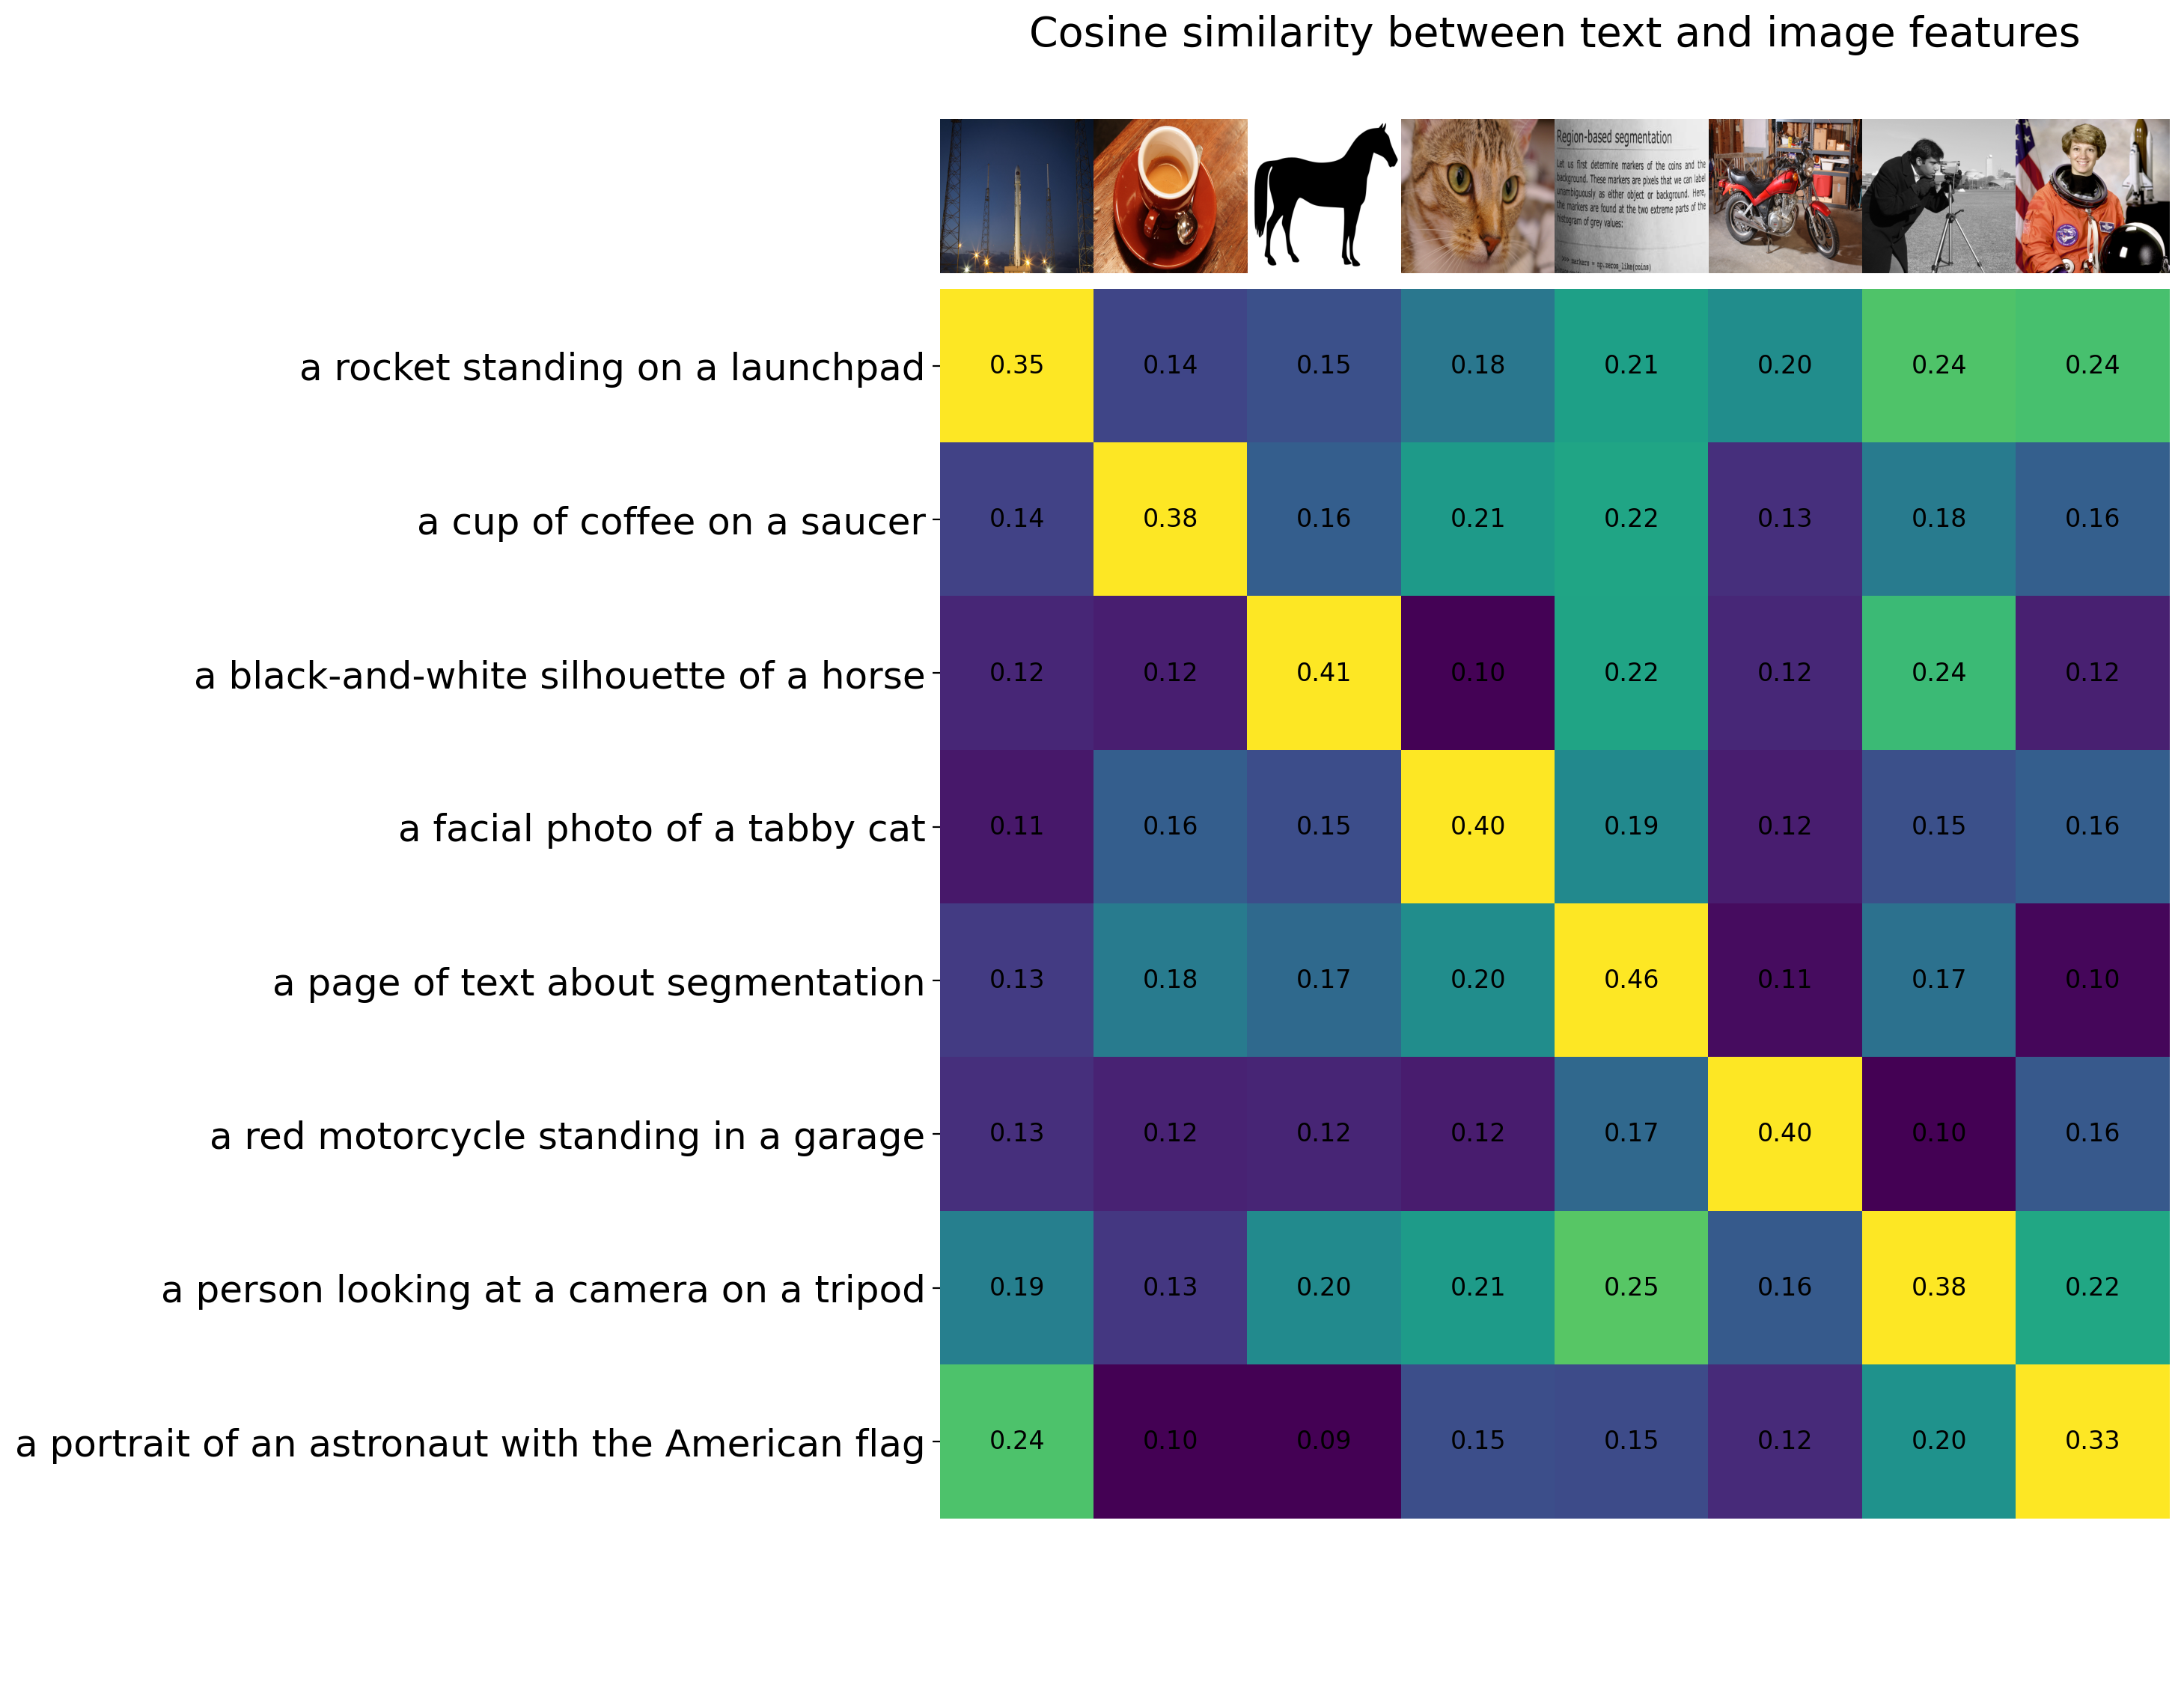

In [45]:
count = len(descriptions)

plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
# plt.colorbar()
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])
for i, image in enumerate(original_images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)

In [46]:
from torchvision.datasets import CIFAR100

cifar100 = CIFAR100(os.path.expanduser("~/.cache"), transform=preprocess, download=True)

In [48]:
cifar100.classes

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [49]:
text_descriptions = [f"A photo of a {label}" for label in cifar100.classes]
text_tokens = tokenizer.tokenize(text_descriptions)

In [50]:
with torch.no_grad():
    text_features = model.encode_text(text_tokens).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

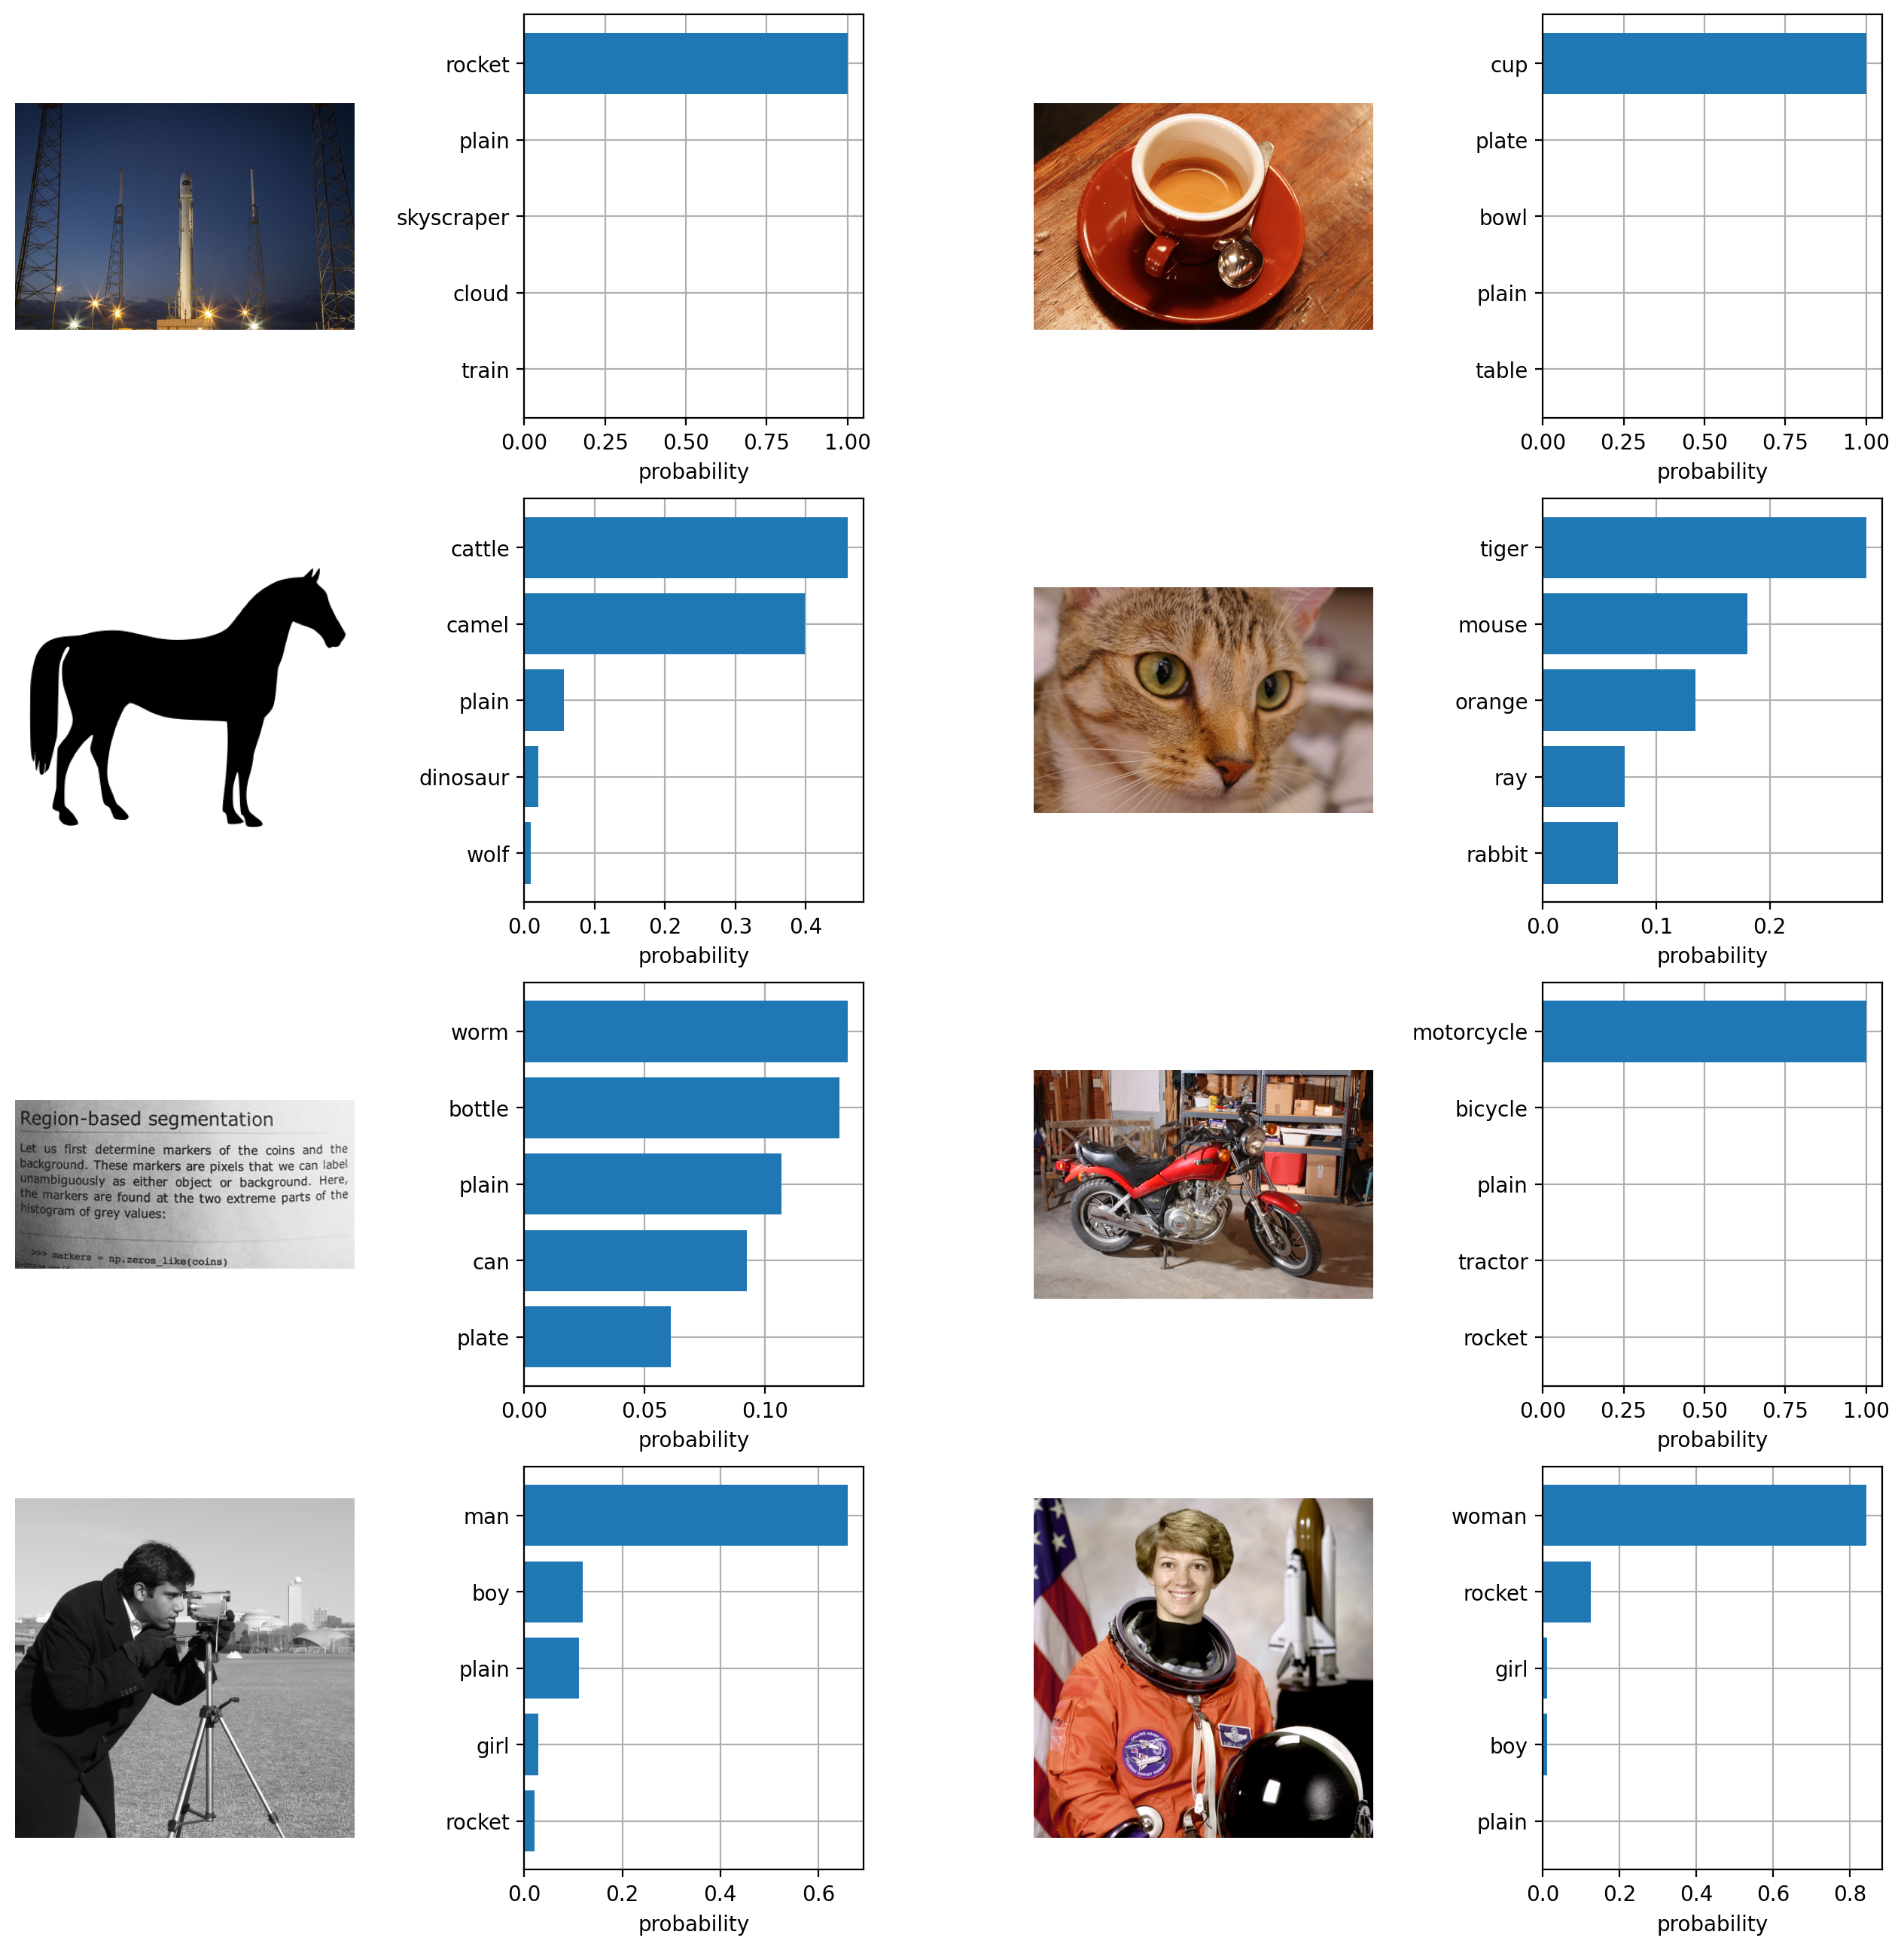

In [53]:
plt.figure(figsize=(16, 16))

for i, image in enumerate(original_images):
    plt.subplot(4, 4, 2 * i + 1)
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(4, 4, 2 * i + 2)
    y = np.arange(top_probs.shape[-1])
    plt.grid()
    plt.barh(y, top_probs[i])
    plt.gca().invert_yaxis()
    plt.gca().set_axisbelow(True)
    plt.yticks(y, [cifar100.classes[index] for index in top_labels[i].numpy()])
    plt.xlabel("probability")

plt.subplots_adjust(wspace=0.5)
plt.show()

In [54]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader

import open_clip
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [69]:
# CLIP transform for images
# (OpenCLIP provides its own preprocessing pipeline)
model_name = "ViT-SO400M-16-SigLIP2-512"
pretrained_tag = "webli"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name, pretrained=pretrained_tag
)
tokenizer = open_clip.get_tokenizer(model_name)
model = model.to(device).eval()

# CIFAR-100 dataset (train split is fine)
cifar_transform = T.Compose([
    T.Resize(512),
    T.CenterCrop(512),
    T.ToTensor()
])

dataset = CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=cifar_transform
)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


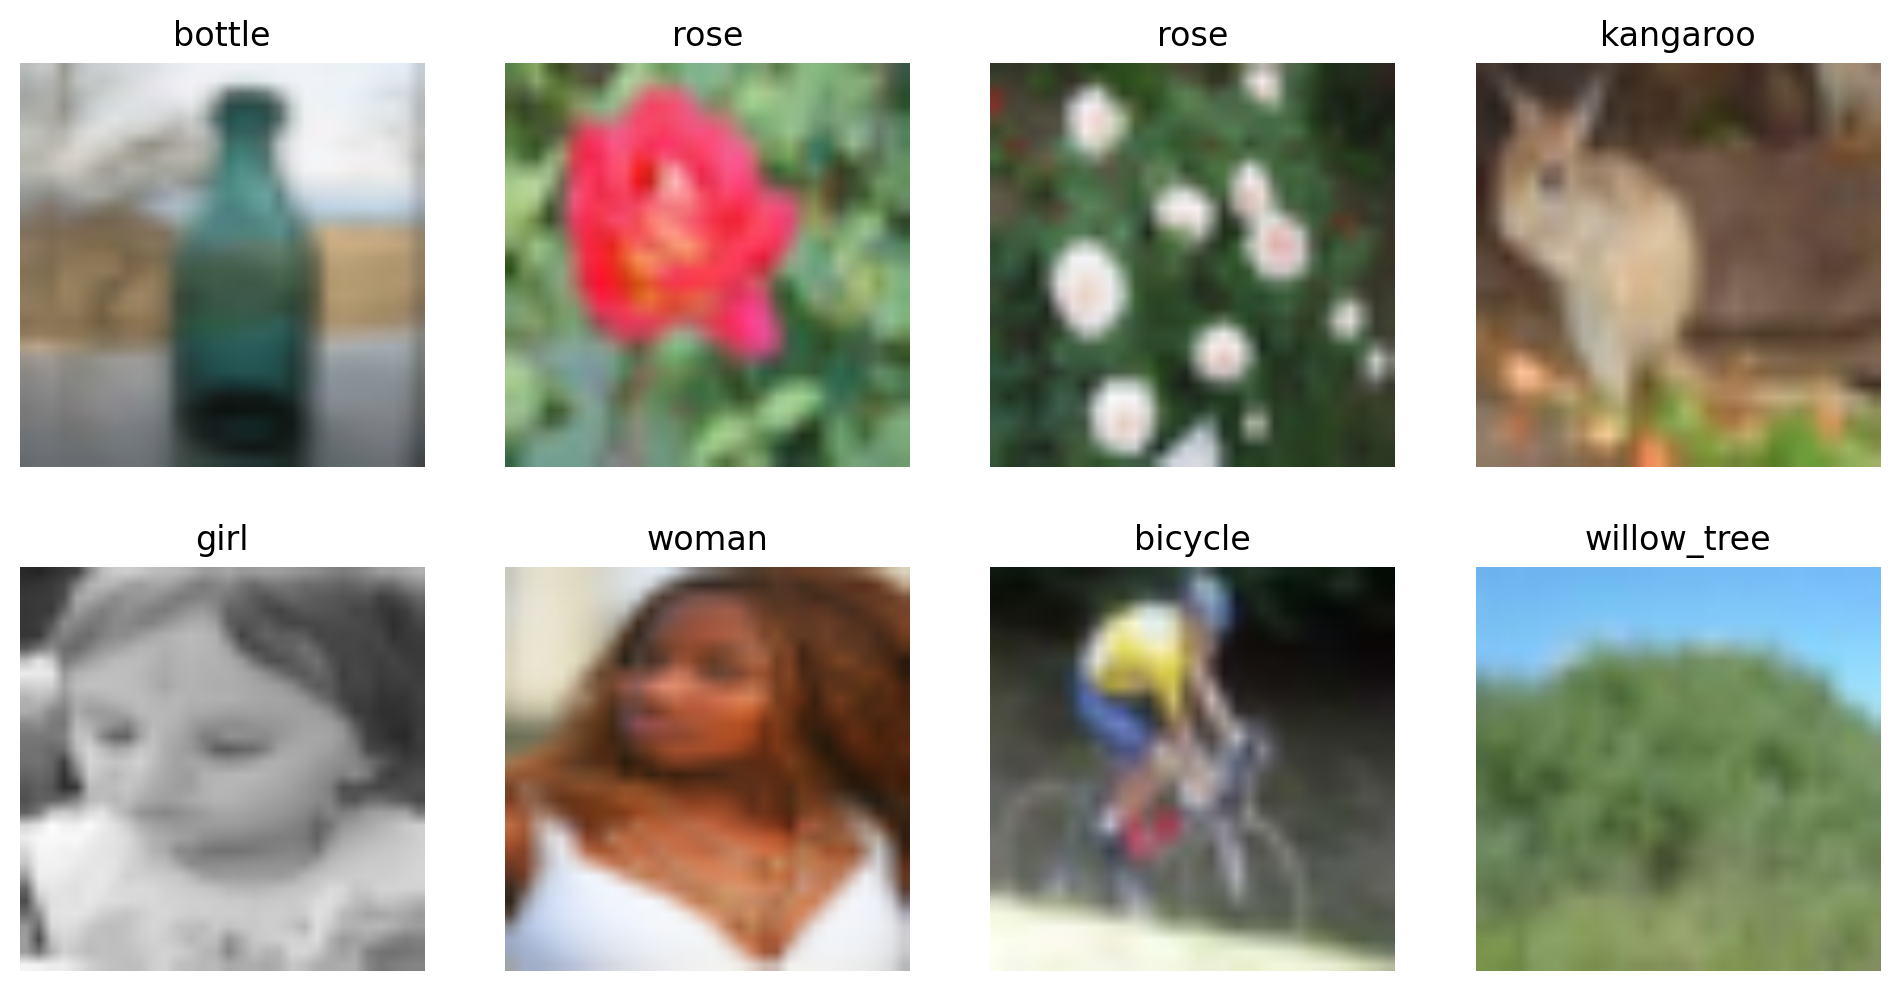

In [70]:
images, labels = next(iter(dataloader))
classes = dataset.classes  # list of 100 class names

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(classes[labels[i]])
    plt.axis("off")


In [71]:
images_clip = images.to(device)

with torch.no_grad():
    image_features = model.encode_image(images_clip)

# Normalize embeddings
image_features = image_features / image_features.norm(dim=-1, keepdim=True)


In [72]:
cifar100_prompts = [f"a photo of a {c}" for c in classes]

# Tokenize the prompts
text_tokens = tokenizer(cifar100_prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)

text_features = text_features / text_features.norm(dim=-1, keepdim=True)


In [73]:
cifar100_prompts[:10]

['a photo of a apple',
 'a photo of a aquarium_fish',
 'a photo of a baby',
 'a photo of a bear',
 'a photo of a beaver',
 'a photo of a bed',
 'a photo of a bee',
 'a photo of a beetle',
 'a photo of a bicycle',
 'a photo of a bottle']

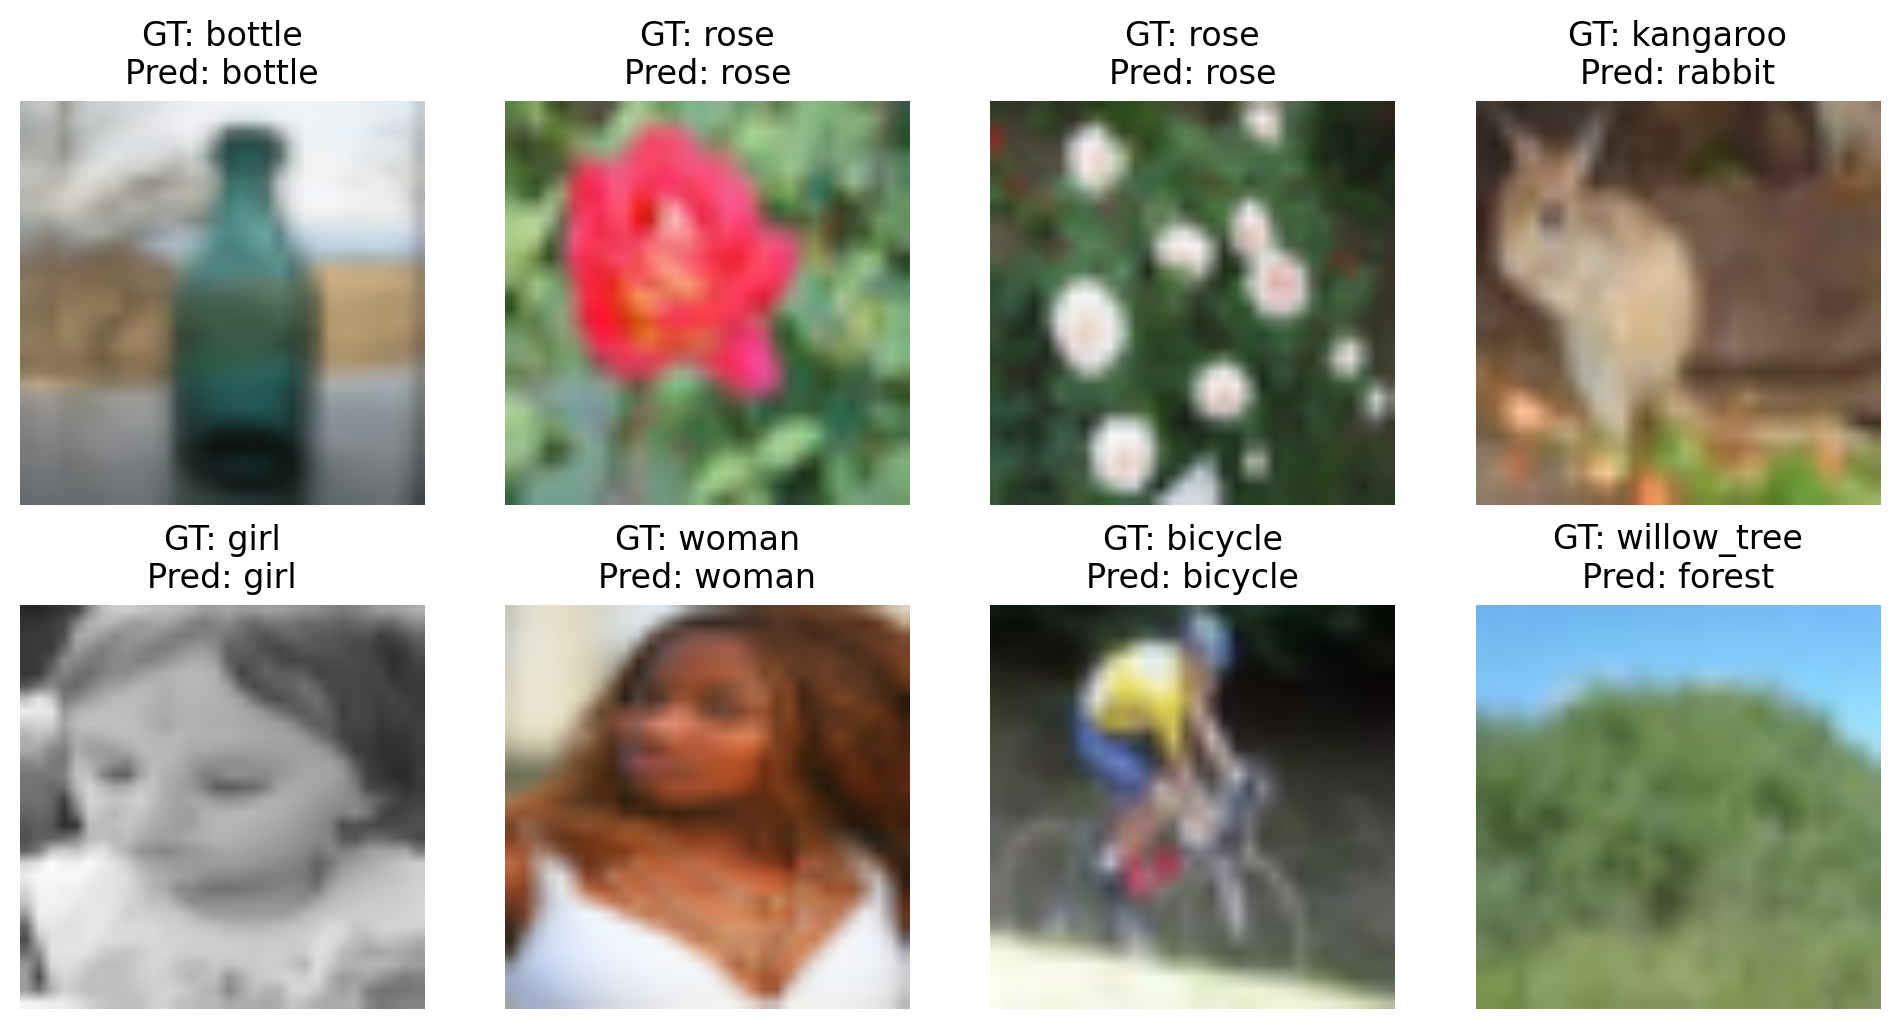

In [74]:
# Compute similarity: (batch_size × 100)
logits = 100.0 * image_features @ text_features.T
probs = logits.softmax(dim=-1)

top_probs, top_idxs = probs.topk(1, dim=-1)
plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i].permute(1,2,0))

    pred_class = classes[top_idxs[i].item()]
    true_class = classes[labels[i]]

    plt.title(f"GT: {true_class}\nPred: {pred_class}")
    plt.axis("off")


In [75]:
test_prompts = [
    "a photo of a dog",
    "a photo of a mushroom",
    "a photo of a house",
    "a photo of a castle",
    "a photo of a frog",
    "a photo of a fish"
]

tokens = tokenizer(test_prompts).to(device)
with torch.no_grad():
    text_feats = model.encode_text(tokens)
text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

# Compare image 0 with these prompts
logits = 100.0 * image_features[0:1] @ text_feats.T
probs = logits.softmax(dim=-1)[0]

for prompt, p in zip(test_prompts, probs):
    print(f"{prompt:30s} → {p.item():.4f}")


a photo of a dog               → 0.1148
a photo of a mushroom          → 0.1199
a photo of a house             → 0.0707
a photo of a castle            → 0.1824
a photo of a frog              → 0.0226
a photo of a fish              → 0.4897
